In [ ]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import glob
import os

In [ ]:
def load_tif(path):
    with rasterio.open(path) as src:
        img = src.read()
    return img

RGB_PATH = load_tif("/content/drive/MyDrive/ALP_Flood_Dataset/Kerala_PostFlood_RGB-0000027136-0000013568.tif")
NDWI_PATH = load_tif("/content/drive/MyDrive/ALP_Flood_Dataset/Kerala_PostFlood_NDWI-0000000000-0000000000.tif")
MASK_PATH = load_tif("/content/drive/MyDrive/ALP_Flood_Dataset/Kerala_NewlyFlooded_Mask.tif")
print(type(RGB_PATH), RGB_PATH)


<class 'numpy.ndarray'> [[[1333.  1375.  1475.  ...  818.   875.   875. ]
  [1170.  1214.  1265.  ...  714.   742.   858. ]
  [1011.  1103.  1076.  ...  626.   682.   892. ]
  ...
  [ 169.5  143.   166.  ... 1340.  1703.  1742. ]
  [ 162.5  150.   165.5 ... 1578.  1644.  1640. ]
  [ 188.   163.5  158.  ... 1032.  1496.  1616. ]]

 [[1450.  1522.  1591.  ...  777.   808.   808. ]
  [1310.  1359.  1393.  ...  703.   728.   796. ]
  [1161.  1232.  1172.  ...  650.   708.   822. ]
  ...
  [ 278.5  254.   271.  ... 1179.  1360.  1347. ]
  [ 262.5  243.   270.  ... 1299.  1260.  1340. ]
  [ 275.5  248.5  281.  ... 1043.  1260.  1298. ]]

 [[1363.  1511.  1523.  ...  687.   702.   702. ]
  [1233.5 1263.5 1338.5 ...  634.   614.   720. ]
  [1081.  1130.5 1033.  ...  597.   588.   728. ]
  ...
  [ 301.   269.   279.5 ...  792.   883.   942.5]
  [ 299.5  283.5  277.5 ...  832.5  911.   923. ]
  [ 286.   292.   284.5 ...  579.   831.   878. ]]]


In [ ]:
BASE_DIR = "/content/drive/MyDrive/ALP_Flood_Dataset"

rgb_files  = sorted(glob.glob(os.path.join(BASE_DIR, "Kerala_PostFlood_RGB-*.tif")))
ndwi_files = sorted(glob.glob(os.path.join(BASE_DIR, "Kerala_PostFlood_NDWI-*.tif")))
mask_files = sorted(glob.glob(os.path.join(BASE_DIR, "Kerala_NewlyFlooded_Mask*.tif")))

print(len(rgb_files), len(ndwi_files), len(mask_files))
print(rgb_files[0])


12 2 1
/content/drive/MyDrive/ALP_Flood_Dataset/Kerala_PostFlood_RGB-0000000000-0000000000.tif


In [ ]:
def patch_generator(rgb_path, ndwi_path, mask_path, patch_size=256):
    with rasterio.open(rgb_path) as rgb_src, \
         rasterio.open(ndwi_path) as ndwi_src, \
         rasterio.open(mask_path) as mask_src:

        for y in range(0, rgb_src.height, patch_size):
            for x in range(0, rgb_src.width, patch_size):

                window = rasterio.windows.Window(x, y, patch_size, patch_size)

                rgb = rgb_src.read([1,2,3], window=window)
                ndwi = ndwi_src.read(1, window=window)
                mask = mask_src.read(1, window=window)

                if rgb.shape[1:] != (patch_size, patch_size):
                    continue

                rgb = np.transpose(rgb, (1,2,0)) / 255.0
                ndwi = ndwi[..., np.newaxis]
                mask = (mask > 0).astype(np.float32)[..., np.newaxis]

                X = np.concatenate([rgb, ndwi], axis=2)
                Y = mask

                flood_ratio = Y.mean()
                if flood_ratio < 0.005:   # < 0.5% flooded pixels
                    continue



                yield X, Y


In [ ]:
gen = patch_generator(rgb_files[0], ndwi_files[0], mask_files[0])
X, Y = next(gen)

print("X:", X.shape)
print("Y:", Y.shape)


X: (256, 256, 4)
Y: (256, 256, 1)


In [ ]:
class FloodNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
model = FloodNet()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.BCEWithLogitsLoss()

step = 0

for rgb_f, ndwi_f, mask_f in zip(rgb_files, ndwi_files, mask_files):
    gen = patch_generator(rgb_f, ndwi_f, mask_f)

    for X, Y in gen:

        # 🔹 REPLACEMENT STARTS HERE
        flood_ratio = Y.mean()
        if flood_ratio < 0.005:   # less than 0.5% flooded pixels
            continue
        # 🔹 REPLACEMENT ENDS HERE

        # Clamp inputs for stability
        X = np.clip(X, 0.0, 1.0)

        X_t = torch.tensor(X).permute(2,0,1).unsqueeze(0).float()
        Y_t = torch.tensor(Y).permute(2,0,1).unsqueeze(0).float()

        optimizer.zero_grad()
        pred = model(X_t)
        loss = criterion(pred, Y_t)

        if not torch.isfinite(loss):
            print("⚠️ Skipping unstable batch")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        if step % 10 == 0:
            print(f"Step {step}, Loss: {loss.item():.4f}")

        step += 1
        if step == 120:
            break

    if step == 120:
        break


Step 0, Loss: 0.6960
Step 10, Loss: 0.6797
Step 20, Loss: 0.6749
Step 30, Loss: 0.6548
Step 40, Loss: 0.6406
Step 50, Loss: 0.6289
⚠️ Skipping unstable batch
⚠️ Skipping unstable batch


KeyboardInterrupt: 

In [ ]:
model.eval()

with torch.no_grad():
    logits = model(X_t)
    probs = torch.sigmoid(logits)
    pred = probs.squeeze().cpu().numpy()

pred_mask = (pred > 0.25).astype(np.uint8)


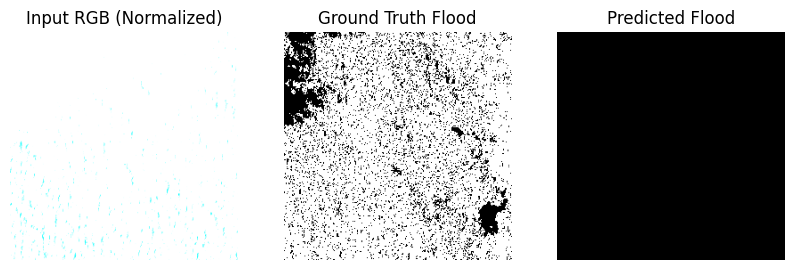

In [ ]:
plt.figure(figsize=(10,3))

# 🔹 Input RGB (FIXED)
plt.subplot(1,3,1)
plt.title("Input RGB (Normalized)")
rgb_vis = X[:,:,:3]
rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
plt.imshow(rgb_vis)
plt.axis("off")

# 🔹 Ground Truth
plt.subplot(1,3,2)
plt.title("Ground Truth Flood")
plt.imshow(Y.squeeze(), cmap="gray")
plt.axis("off")

# 🔹 Predicted Flood
plt.subplot(1,3,3)
plt.title("Predicted Flood")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(4, 32)
        self.enc2 = DoubleConv(32, 64)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)

        # Decoder
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        # Bottleneck
        b = self.bottleneck(self.pool(e2))

        # Decoder
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
model = UNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
# Initialize model, loss, optimizer
model = UNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

model.train()

step = 0
MAX_STEPS = 120   # enough for 3rd review

for rgb_f, ndwi_f, mask_f in zip(rgb_files, ndwi_files, mask_files):

    gen = patch_generator(rgb_f, ndwi_f, mask_f)

    for X, Y in gen:

        # 🔹 Skip almost-empty flood patches (class imbalance handling)
        flood_ratio = Y.mean()
        if flood_ratio < 0.005:   # < 0.5% flood pixels
            continue

        # 🔹 Clamp inputs for numerical stability
        X = np.clip(X, 0.0, 1.0)

        # 🔹 Convert to torch tensors
        X_t = torch.tensor(X).permute(2, 0, 1).unsqueeze(0).float()
        Y_t = torch.tensor(Y).permute(2, 0, 1).unsqueeze(0).float()

        optimizer.zero_grad()

        # 🔹 Forward pass
        logits = model(X_t)
        loss = criterion(logits, Y_t)

        # 🔹 Skip NaN / Inf loss (safety net)
        if not torch.isfinite(loss):
            print("⚠️ Skipping unstable batch")
            continue

        # 🔹 Backpropagation
        loss.backward()

        # 🔹 Gradient clipping (VERY IMPORTANT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

        optimizer.step()

        # 🔹 Logging
        if step % 10 == 0:
            print(f"Step {step}, Loss: {loss.item():.4f}")

        step += 1
        if step >= MAX_STEPS:
            break

    if step >= MAX_STEPS:
        break

Step 0, Loss: 0.6153
Step 10, Loss: 0.5977
Step 20, Loss: 0.6228
Step 30, Loss: 0.5543
Step 40, Loss: 0.5127
Step 50, Loss: 0.4697
⚠️ Skipping unstable batch
⚠️ Skipping unstable batch
Step 60, Loss: 0.4060
Step 70, Loss: 0.3098
Step 80, Loss: 0.1341
Step 90, Loss: 0.0464
Step 100, Loss: 0.2134
⚠️ Skipping unstable batch
⚠️ Skipping unstable batch
⚠️ Skipping unstable batch
Step 110, Loss: 0.1341
⚠️ Skipping unstable batch


In [ ]:
model.eval()

with torch.no_grad():
    logits = model(X_t)
    probs = torch.sigmoid(logits)
    pred = probs.squeeze().cpu().numpy()

# Lower threshold for flood detection
pred_mask = (pred > 0.25).astype(np.uint8)

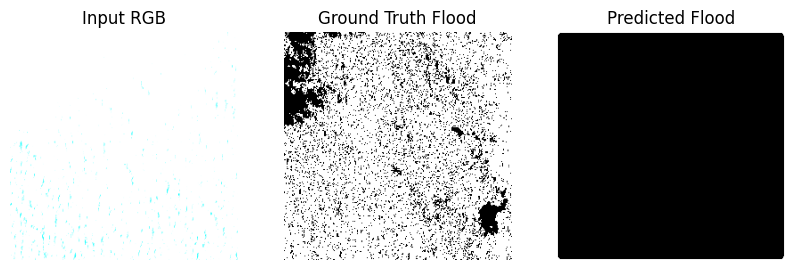

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

# Input RGB (normalized for display)
plt.subplot(1,3,1)
plt.title("Input RGB")
rgb_vis = X[:,:,:3]
rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
plt.imshow(rgb_vis)
plt.axis("off")

# Ground truth
plt.subplot(1,3,2)
plt.title("Ground Truth Flood")
plt.imshow(Y.squeeze(), cmap="gray")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.title("Predicted Flood")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()

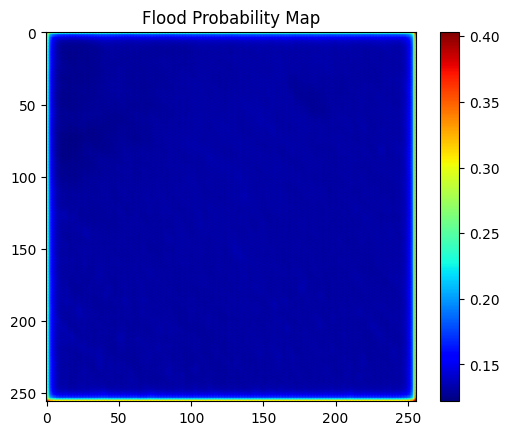

In [ ]:
plt.imshow(pred, cmap="jet")
plt.colorbar()
plt.title("Flood Probability Map")
plt.show()

In [ ]:
# Calculate flood percentage
total_pixels = pred_mask.size
flood_pixels = pred_mask.sum()

flood_percentage = (flood_pixels / total_pixels) * 100

# Classify severity
if flood_percentage < 10:
    severity = "Low Flood Severity"
elif flood_percentage < 30:
    severity = "Medium Flood Severity"
else:
    severity = "High Flood Severity"

print(f"Flooded Area: {flood_percentage:.2f}%")
print(f"Flood Severity Level: {severity}")

Flooded Area: 1.58%
Flood Severity Level: Low Flood Severity


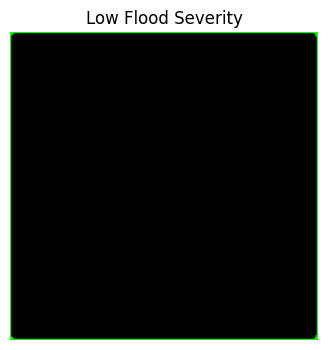

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

severity_map = np.zeros((*pred_mask.shape, 3))

if severity == "Low Flood Severity":
    severity_map[pred_mask == 1] = [0, 1, 0]   # Green
elif severity == "Medium Flood Severity":
    severity_map[pred_mask == 1] = [1, 1, 0]   # Yellow
else:
    severity_map[pred_mask == 1] = [1, 0, 0]   # Red

plt.figure(figsize=(4,4))
plt.imshow(severity_map)
plt.title(severity)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

# Flatten masks
y_true = Y.squeeze().astype(np.uint8).flatten()
y_pred = pred_mask.astype(np.uint8).flatten()

# Pixel Accuracy
pixel_accuracy = (y_true == y_pred).sum() / len(y_true)

# IoU calculation
intersection = np.logical_and(y_true == 1, y_pred == 1).sum()
union = np.logical_or(y_true == 1, y_pred == 1).sum()

iou = intersection / union if union != 0 else 0

print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
print(f"IoU (Flood Class): {iou:.4f}")

Pixel Accuracy: 0.1882
IoU (Flood Class): 0.0148


In [ ]:
HIGH_FLOOD_THRESHOLD = 50  # percent

found = False

for rgb_f, ndwi_f, mask_f in zip(rgb_files, ndwi_files, mask_files):
    gen = patch_generator(rgb_f, ndwi_f, mask_f)

    for X, Y in gen:
        flood_percentage = (Y.sum() / Y.size) * 100

        if flood_percentage > HIGH_FLOOD_THRESHOLD:
            print(f"✅ High flood patch found: {flood_percentage:.2f}% flooded")

            found = True
            break

    if found:
        break

✅ High flood patch found: 60.82% flooded


In [ ]:
model.eval()

with torch.no_grad():
    logits = model(torch.tensor(X).permute(2,0,1).unsqueeze(0).float())
    probs = torch.sigmoid(logits)
    pred = probs.squeeze().cpu().numpy()

pred_mask = (pred > 0.25).astype(np.uint8)

In [ ]:
# Severity based on ground truth (NDWI-based flood extent)
gt_flood_percentage = (Y.sum() / Y.size) * 100

if gt_flood_percentage < 10:
    gt_severity = "Low Flood Severity"
elif gt_flood_percentage < 30:
    gt_severity = "Medium Flood Severity"
else:
    gt_severity = "High Flood Severity"

print(f"Ground Truth Flood Area: {gt_flood_percentage:.2f}%")
print(f"Ground Truth Flood Severity: {gt_severity}")

Ground Truth Flood Area: 60.82%
Ground Truth Flood Severity: High Flood Severity


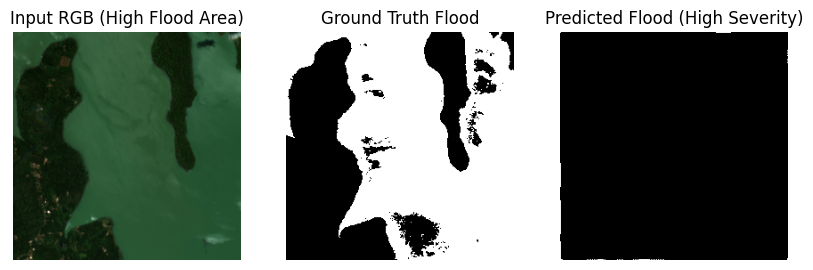

In [ ]:
plt.figure(figsize=(10,3))

# RGB
plt.subplot(1,3,1)
plt.title("Input RGB (High Flood Area)")
rgb_vis = X[:,:,:3]
rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
plt.imshow(rgb_vis)
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.title("Ground Truth Flood")
plt.imshow(Y.squeeze(), cmap="gray")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.title("Predicted Flood (High Severity)")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
model.eval()

with torch.no_grad():
    logits = model(torch.tensor(X).permute(2,0,1).unsqueeze(0).float())
    probs = torch.sigmoid(logits)
    pred = probs.squeeze().cpu().numpy()

In [ ]:
demo_pred_mask = (pred > 0.15).astype(np.uint8)

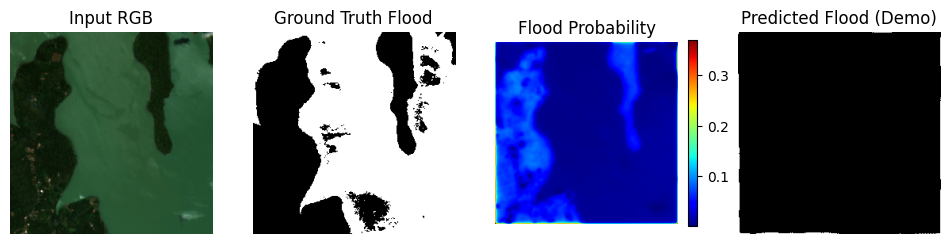

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))

# 1️⃣ Input RGB
plt.subplot(1,4,1)
plt.title("Input RGB")
rgb_vis = X[:,:,:3]
rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
plt.imshow(rgb_vis)
plt.axis("off")

# 2️⃣ Ground Truth
plt.subplot(1,4,2)
plt.title("Ground Truth Flood")
plt.imshow(Y.squeeze(), cmap="gray")
plt.axis("off")

# 3️⃣ Flood Probability Map
plt.subplot(1,4,3)
plt.title("Flood Probability")
plt.imshow(pred, cmap="jet")
plt.colorbar(fraction=0.046)
plt.axis("off")

# 4️⃣ Predicted Flood (Demo)
plt.subplot(1,4,4)
plt.title("Predicted Flood (Demo)")
plt.imshow(demo_pred_mask, cmap="gray")
plt.axis("off")

plt.show()